# Tugas Linier Regression

## 1. Dataset
Berdasarkan data titik koordinat $(x, y)$ yang diambil dari GeoGebra, didapatkan $n = 7$ data sebagai berikut:
* $A(2,2)$
* $B(4,3)$
* $C(3,5)$
* $D(3,4)$
* $E(3,3)$
* $F(4,5)$
* $G(5,6)$

## 2. Perhitungan secara Analitik (Manual)

Untuk mencari koefisien regresi $\beta_0$ (intercept) dan $\beta_1$ (slope) secara analitik, kita menggunakan **Persamaan Normal (Normal Equation)**:

$$\hat{\beta} = (X^T X)^{-1} X^T Y$$

Di mana:
* $\hat{\beta}$ adalah vektor parameter yang berisi $\beta_0$ (*intercept*) dan $\beta_1$ (*slope*/koefisien).
* $X$ adalah matriks fitur/prediktor (ditambahkan kolom basis $1$ untuk *intercept*).
* $Y$ adalah vektor target/label.


### Langkah 1: Inisialisasi Struktur Matriks Awal

Berdasarkan $n = 7$ data koordinat dari GeoGebra, setiap data memenuhi persamaan linier $y_i = \beta_0(1) + \beta_1 x_i$. Kita dapat menyusun data tersebut ke dalam bentuk matriks berikut:

$$Y = \begin{pmatrix} 2 \\ 3 \\ 5 \\ 4 \\ 3 \\ 5 \\ 6 \end{pmatrix}$$

$$X = \begin{pmatrix} 1 & 2 \\ 1 & 4 \\ 1 & 3 \\ 1 & 3 \\ 1 & 3 \\ 1 & 4 \\ 1 & 5 \end{pmatrix}$$

> **Catatan:** Kolom pertama pada matriks $X$ yang berisi angka $1$ berfungsi sebagai komponen pengali konstanta $\beta_0$ agar *intercept* dapat dihitung secara bersamaan dalam operasi matriks.

---

### Langkah 2: Menghitung Matriks $X^T X$

Pertama, lakukan operasi *transpose* pada matriks $X$ (mengubah baris menjadi kolom):

$$X^T = \begin{pmatrix} 1 & 1 & 1 & 1 & 1 & 1 & 1 \\ 2 & 4 & 3 & 3 & 3 & 4 & 5 \end{pmatrix}$$

Selanjutnya, kalikan matriks $X^T$ dengan $X$ menggunakan aturan perkalian matriks (Baris $\times$ Kolom):

$$X^T X = \begin{pmatrix} 1 & 1 & 1 & 1 & 1 & 1 & 1 \\ 2 & 4 & 3 & 3 & 3 & 4 & 5 \end{pmatrix} \begin{pmatrix} 1 & 2 \\ 1 & 4 \\ 1 & 3 \\ 1 & 3 \\ 1 & 3 \\ 1 & 4 \\ 1 & 5 \end{pmatrix}$$

Kalkulasi detail setiap elemen matriks:
* **Baris 1, Kolom 1 ($n$):**
  $(1\times1) + (1\times1) + (1\times1) + (1\times1) + (1\times1) + (1\times1) + (1\times1) = 7$

* **Baris 1, Kolom 2 ($\sum x$):**
  $(1\times2) + (1\times4) + (1\times3) + (1\times3) + (1\times3) + (1\times4) + (1\times5) = 24$

* **Baris 2, Kolom 1 ($\sum x$):**
  $(2\times1) + (4\times1) + (3\times1) + (3\times1) + (3\times1) + (4\times1) + (5\times1) = 24$

* **Baris 2, Kolom 2 ($\sum x^2$):**
  $(2\times2) + (4\times4) + (3\times3) + (3\times3) + (3\times3) + (4\times4) + (5\times5) = 4 + 16 + 9 + 9 + 9 + 16 + 25 = 88$

Maka diperoleh hasil:
$X^T X = \begin{pmatrix} 7 & 24 \\ 24 & 88 \end{pmatrix}$

---

### Langkah 3: Menghitung Matriks $X^T Y$

Kalikan matriks $X^T$ dengan vektor target $Y$:

$X^T Y = \begin{pmatrix} 1 & 1 & 1 & 1 & 1 & 1 & 1 \\ 2 & 4 & 3 & 3 & 3 & 4 & 5 \end{pmatrix} \begin{pmatrix} 2 \\ 3 \\ 5 \\ 4 \\ 3 \\ 5 \\ 6 \end{pmatrix}$

Kalkulasi detail setiap elemen vektor:
* **Baris 1 ($\sum y$):**
  $(1\times2) + (1\times3) + (1\times5) + (1\times4) + (1\times3) + (1\times5) + (1\times6) = 2 + 3 + 5 + 4 + 3 + 5 + 6 = 28$

* **Baris 2 ($\sum xy$):**
  $(2\times2) + (4\times3) + (3\times5) + (3\times4) + (3\times3) + (4\times5) + (5\times6) = 4 + 12 + 15 + 12 + 9 + 20 + 30 = 102$

Maka diperoleh hasil:
$X^T Y = \begin{pmatrix} 28 \\ 102 \end{pmatrix}$

---

### Langkah 4: Menghitung Invers Matriks $(X^T X)^{-1}$

Menggunakan rumus invers matriks ordo $2 \times 2$:
$$\begin{pmatrix} a & b \\ c & d \end{pmatrix}^{-1} = \frac{1}{ad - bc} \begin{pmatrix} d & -b \\ -c & a \end{pmatrix}$$

1. **Hitung Determinan ($ad - bc$):**

   $$\text{Determinan} = (7 \times 88) - (24 \times 24) = 616 - 576 = 40$$

2. **Substitusi nilai ke dalam rumus invers:**

   $$(X^T X)^{-1} = \frac{1}{40} \begin{pmatrix} 88 & -24 \\ -24 & 7 \end{pmatrix}$$

---

### Langkah 5: Perkalian Akhir Menentukan Vektor Parameter $\hat{\beta}$

Langkah terakhir adalah mengalikan hasil invers matriks dengan vektor $X^T Y$:

$$\hat{\beta} = \frac{1}{40} \begin{pmatrix} 88 & -24 \\ -24 & 7 \end{pmatrix} \begin{pmatrix} 28 \\ 102 \end{pmatrix}$$

Lakukan perkalian matriks bagian dalam terlebih dahulu:
* **Elemen Baris 1:**

  $$(88 \times 28) + (-24 \times 102) = 2464 - 2448 = 16$$

* **Elemen Baris 2:**

  $$(-24 \times 28) + (7 \times 102) = -672 + 714 = 42$$

Sekarang kalikan nilai skalar determinan ($\frac{1}{40}$) ke dalam hasil di atas:

$$\hat{\beta} = \begin{pmatrix} \beta_0 \\ \beta_1 \end{pmatrix} = \begin{pmatrix} \frac{16}{40} \\ \frac{42}{40} \end{pmatrix} = \begin{pmatrix} 0.4 \\ 1.05 \end{pmatrix}$$

> **Hasil Analitik:** Intercept ($\beta_0$) = **0.4**, Koefisien ($\beta_1$) = **1.05**


## 3. Implementasi Program Python

Berikut adalah program Python untuk membandingkan hasil estimasi menggunakan library `scikit-learn` dengan formula analitik menggunakan `NumPy`.

In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. INPUT DATA DARI GEOGEBRA
# Matriks X (Fitur/Prediktor) harus dalam bentuk 2D array [[x]]
X = np.array([[2], [4], [3], [3], [3], [4], [5]])
Y = np.array([[2], [3], [5], [4], [3], [5], [6]])

print("======= METODE 1: SKLEARN =======")
# Inisialisasi dan latih model
model = LinearRegression()
model.fit(X, Y)

# Mengambil hasil koefisien dari sklearn
intercept_sklearn = model.intercept_[0]
coef_sklearn = model.coef_[0][0]

print(f"Intercept (beta_0) : {intercept_sklearn:.4f}")
print(f"Koefisien (beta_1) : {coef_sklearn:.4f}")


print("\n======= METODE 2: ANALITIK (NUMPY) =======")
# Menambahkan kolom angka 1 untuk matriks intercept
X_bias = np.c_[np.ones((X.shape[0], 1)), X]

# Menghitung dengan rumus: (X^T * X)^(-1) * X^T * Y
beta_analitik = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ Y

print(f"Intercept (beta_0) : {beta_analitik[0][0]:.4f}")
print(f"Koefisien (beta_1) : {beta_analitik[1][0]:.4f}")

======= METODE 1: SKLEARN =======
Intercept (beta_0) : 0.4000
Koefisien (beta_1) : 1.0500

======= METODE 2: ANALITIK (NUMPY) =======
Intercept (beta_0) : 0.4000
Koefisien (beta_1) : 1.0500


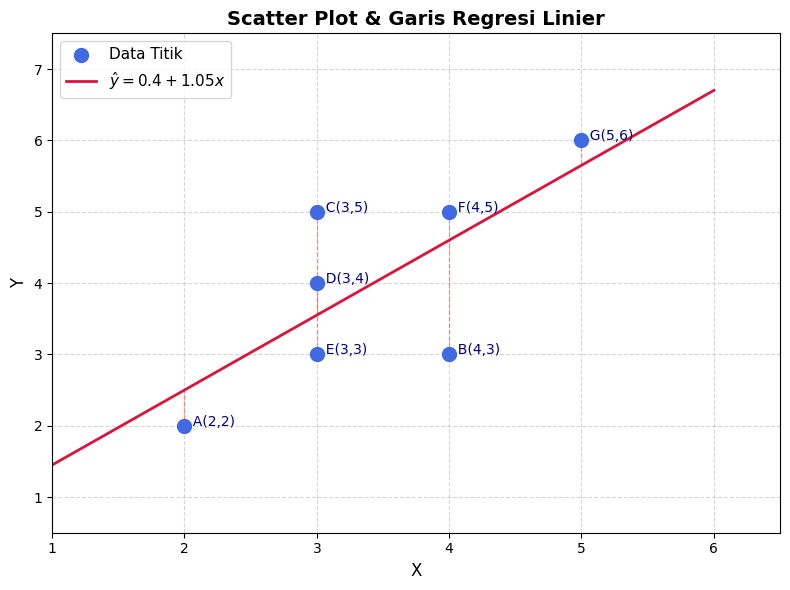

Persamaan Regresi: y_hat = 0.4 + 1.05x


In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Data
X_vals = np.array([2, 4, 3, 3, 3, 4, 5])
Y_vals = np.array([2, 3, 5, 4, 3, 5, 6])
labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

# Parameter hasil regresi
beta_0 = 0.4
beta_1 = 1.05

# Garis regresi
x_line = np.linspace(1, 6, 100)
y_line = beta_0 + beta_1 * x_line

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot titik data
ax.scatter(X_vals, Y_vals, color='royalblue', s=100, zorder=5, label='Data Titik')

# Label setiap titik
for i, txt in enumerate(labels):
    ax.annotate(f'  {txt}({X_vals[i]},{Y_vals[i]})',
                (X_vals[i], Y_vals[i]),
                fontsize=10, color='navy')

# Residual lines (garis vertikal dari titik ke garis regresi)
for xi, yi in zip(X_vals, Y_vals):
    y_pred_i = beta_0 + beta_1 * xi
    ax.plot([xi, xi], [yi, y_pred_i], color='tomato', linestyle='--', linewidth=0.9, alpha=0.7)

# Garis regresi
ax.plot(x_line, y_line, color='crimson', linewidth=2,
        label=r'$\hat{y} = 0.4 + 1.05x$')

# Styling
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_title('Scatter Plot & Garis Regresi Linier', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlim(1, 6.5)
ax.set_ylim(0.5, 7.5)

plt.tight_layout()
plt.savefig('../img/lin_matplotlib.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Persamaan Regresi: y_hat = {beta_0} + {beta_1}x')

## 4. Implementasi ke Geogebra

Berdasarkan simulasi dan grafik yang dihasilkan melalui *GeoGebra Calculator Suite*, berikut adalah analisis mengenai sebaran data serta interpretasi dari garis regresi yang terbentuk.

---
![geoalgebra](../img/geogebra.jpeg)

### Distribusi Data (Scatter Plot)
Data terdiri dari 7 titik koordinat pada bidang Kartesius: 
* $A(2,2)$, $B(4,3)$, $C(3,5)$, $D(3,4)$, $E(3,3)$, $F(4,5)$, dan $G(5,6)$.

Secara visual, pergerakan titik-titik data menunjukkan tren naik dari kiri bawah ke kanan atas. Hal ini mengindikasikan adanya **korelasi positif** yang kuat antara variabel bebas ($X$) dan variabel terikat ($Y$). Artinya, pertambahan nilai $X$ cenderung diikuti dengan peningkatan nilai $Y$.

### Evaluasi Model
Garis regresi linier yang diperoleh adalah:

$$\hat{y} = 0.4 + 1.05x$$

Jika dianalisis dari grafiknya, garis regresi memotong secara optimal di tengah-tengah sebaran data. Jarak vertikal (*residual*) antara titik-titik data di atas dan di bawah garis berada dalam proporsi yang seimbang, yang menunjukkan bahwa model telah meminimalkan jumlah kuadrat *residual* (metode OLS).

**Kesimpulan:** Hasil pemodelan otomatis oleh GeoGebra menunjukkan hasil yang **identik (konsisten)** dengan perhitungan analitik menggunakan matriks OLS maupun hasil komputasi menggunakan library `scikit-learn` pada Python. Hal ini membuktikan validitas dari perhitungan parameter yang telah dilakukan.